# Working with Missing Data
v.ekc

Missing data is one of the most common and most dangerous issues you'll face in real-world data analysis. We've handled it before by dropping rows or columns, but is that always the right call? Spoiler: **no.** The way you handle missing data can completely change your conclusions.

Today we'll learn to think critically about *why* data is missing and pick the right strategy for dealing with it.

| Section | Topic |
|---------|-------|
| 1 | Setup & Data |
| 2 | Why Missing Data Matters |
| 3 | Three Types of Missing Data (MCAR, MAR, MNAR) |
| 4 | The Impact of Missing Data on Analysis |
| 5 | Detecting Missingness Patterns |
| 6 | Visualizing Missingness with `missingno` |
| 7 | Handling Missing Data: Simple Imputation |
| 8 | Handling Missing Data: Time Series Methods |
| 9 | Open Exploration: Lake Mendocino |
| Appendix | Quick Reference |

---
## 1. Setup & Data

In [58]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(3)

### ETL

We'll be working with a fabricated gender wage dataset throughout this lecture. Let's load it and take a look.

In [59]:
# Read in example dataset (fabricated for this demo)
df = pd.read_csv('gender_wage_full_data.csv')
df.head()

,gender,age,salary
0,male,40,72309.473231
1,female,51,75554.863195
2,male,42,80092.496309
3,male,52,86155.640175
4,male,22,49851.015383


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  500 non-null    str    
 1   age     500 non-null    int64  
 2   salary  500 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 11.8 KB


In [61]:
df.describe()

,age,salary
count,500.000000,500.000000
mean,40.136000,70195.816982
std,11.599595,12149.317412
min,20.000000,42993.842303
25%,31.000000,60097.312017
50%,41.000000,70664.911141
75%,50.000000,79102.104202
max,60.000000,95671.128247


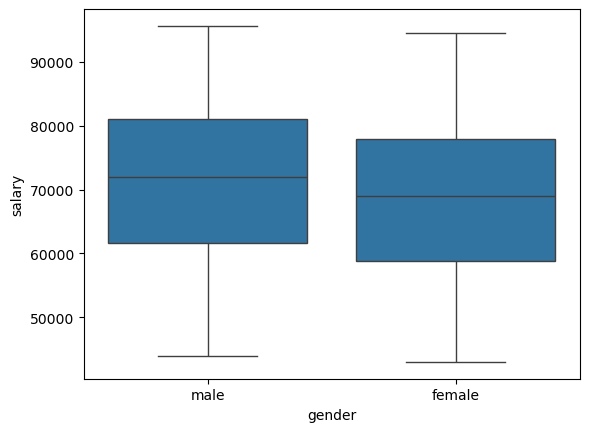

In [62]:
# Quick look at the salary distribution by gender
sns.boxplot(data=df, x='gender', y='salary');

This is our **complete** dataset — no missing values. We'll use it as our ground truth to see how different types of missingness affect our analysis.

---
## 2. Why Missing Data Matters

We've already encountered missing data in this class. Our go-to solution has usually been to drop columns with lots of missing values or remove rows with missing data.

**But is that always okay?**

> The **type** of missing data and our **intended analysis** influences how we should handle missing data.

### What causes missing data?

Missing data can come from many sources:
- Weather conditions or equipment malfunction
- Funding constraints or convenience sampling
- Human error (forgot to record a measurement)
- Survey respondents skipping sensitive questions
- Cloud cover blocking satellite observations
- ... and many more!

### How common is it?

More common than you'd think:
- In the global population dynamics database, **65%** of time series have at least one missing value, and **42%** have over 30% missing
- In a global insect assemblages database, **59%** of 1600 time series have at least one missing value

The question isn't *if* you'll encounter missing data but *how* you'll handle it.

### Discussion: Think before you drop

**Scenario:** You're working on a report about **gender pay gaps** using survey data. Your goal is to determine if there is a significant difference in average income by gender.

Some respondents didn't report their income. Would you just drop those rows? What if the people who skipped the income question tend to be lower-income? What if mostly young men skipped it?

> The answer depends on **why** the data is missing. Let's formalize this.

---
## 3. Three Types of Missing Data

### 📋 Board Reference

| Type | Full Name | Probability of being missing... | Example |
|------|-----------|-------------------------------|---------|
| **MCAR** | Missing Completely at Random | Same for all observations (no pattern, random) | Employees randomly forget to submit a survey |
| **MAR** | Missing at Random | Related to *other* variables in the dataset | "When was your last checkup?" skipped more by young males |
| **MNAR** | Missing Not at Random | Related to the *missing value itself* | "How much have you saved for retirement?" skipped by low-income people |

### MCAR: Missing Completely at Random

All observations have the **same probability** of being missing. The missingness has nothing to do with any variable in the dataset.

**Example:** Some employees forget to submit responses to a workplace satisfaction survey before the deadline. Whether someone forgot is unrelated to their satisfaction level, age, gender, or department. They just forgot.

> MCAR is the "best case" for missing data. Dropping these rows won't introduce bias — you just lose some statistical power.

### MAR: Missing at Random

The probability of being missing is related to the value of **other observed variables** in the dataset. Not all observations have the same chance of being missing.

**Example:** A health survey asks "When was your last routine checkup?" Young males are *apparently* less likely to answer this question! not because of the checkup date itself, but because of their age and gender (which we *can* observe).

> MAR is trickier. Dropping rows can introduce bias because the remaining data is no longer representative of the full population.

### MNAR: Missing Not at Random

The probability of being missing depends on the **value of the missing variable itself** (or for completely unknown reasons).

**Example:** A survey asks "How much have you saved for retirement?" People with low savings are more likely to skip this question. The missingness is directly related to the (unobserved) value.

> MNAR is the hardest to deal with. You can't fully fix it with the data you have, because the missing values are systematically different from the observed ones.

---
### Try It 1: Classify the Missingness 😊

For each scenario below, decide: is the missing data most likely **MCAR**, **MAR**, or **MNAR**? Discuss with a neighbor!

1. A weather station's temperature sensor occasionally malfunctions during thunderstorms, leaving gaps in the temperature record.

2. In a student survey, some students didn't report their GPA. You notice that students who reported lower course loads were more likely to skip the GPA question.

3. A hospital database has missing blood pressure readings. A nurse accidentally skipped recording values for random patients throughout the day.

4. An online retailer's dataset has missing product reviews. Customers who had a bad experience are less likely to leave a review (they just never come back).

In [63]:
# 1. classify the missingness type


In [64]:
# 2. classify the missingness type


In [65]:
# 3. classify the missingness type


In [66]:
# 4. classify the missingness type


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Think about what's driving the missingness — is it random, related to something you can see, or related to the missing value itself?*

1. **MAR**: the missingness is related to weather conditions (thunderstorms), which is an observable variable, not the temperature value itself.

2. **MAR or MNAR**: the missingness is related to course load (observed), not directly to the GPA value itself. Though it *could* be MNAR if students with low GPAs are also skipping...

3. **MCAR**: the nurse randomly skipped patients, unrelated to their actual blood pressure values or any other variable.

4. **MNAR**: the missingness is related to the experience itself (bad experience = no review), which is what the review would have measured.

</details>

---
## 4. The Impact of Missing Data on Analysis

Let's see this in action. We'll take our complete gender wage dataset and **simulate** three types of missingness. Then we'll run the same analysis on each to see how the results change.

Our analysis: a **permutation test** to determine if there's a significant difference in average salary between genders.

In [67]:
# Function for permutation test to determine if difference in means is significant
def permutation_test(data, group_col, value_col):
    observed_diff = data.groupby(group_col)[value_col].mean().diff().iloc[-1]
    diffs = []
    for i in range(5000):
        shuffled = data[value_col].sample(frac=1, replace=False).reset_index(drop=True)
        shuffled_df = data.copy()
        shuffled_df[value_col] = shuffled
        diff = shuffled_df.groupby(group_col)[value_col].mean().diff().iloc[-1]
        diffs.append(diff)
    p_val = np.mean(np.abs(diffs) >= np.abs(observed_diff))
    return observed_diff, p_val, diffs

### Baseline: the complete data

First, let's run the test on the full dataset with no missing values to establish our ground truth.

In [68]:
# Permutation test on the COMPLETE data
obs_diff, p_val, diffs = permutation_test(df, "gender", "salary")

np.float64(0.0092)

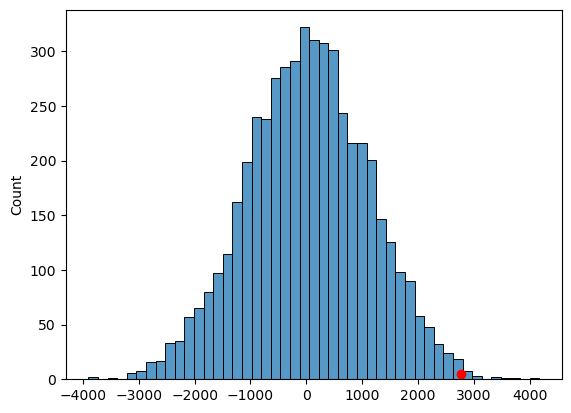

In [69]:
# Visualize results
sns.histplot(diffs)
plt.scatter(x=obs_diff, y=5, marker='o', color='r')
p_val

Now let's see what happens when we introduce different types of missingness and just **drop** the missing rows.

### Simulate MCAR, random 15% removal

In [74]:
# Randomly remove 15% of salaries (MCAR)
n = df.shape[0]
data_random_missing = df.copy()
mask = np.random.rand(n) < 0.15
data_random_missing.loc[mask, 'salary'] = np.nan
data_random_missing.head(10)

,gender,age,salary
0,male,40,72309.473231
1,female,51,NaN
2,male,42,80092.496309
3,male,52,86155.640175
4,male,22,49851.015383
5,female,37,64238.645288
6,male,44,72497.526986
7,male,50,76468.801076
8,male,22,57704.710190
9,female,59,NaN


In [75]:
# Drop the rows with missing salary
data_random_missing_orig = data_random_missing.copy()
data_random_missing.dropna(subset='salary', inplace=True)
data_random_missing.shape

(423, 3)

In [76]:
# Permutation test after dropping MCAR
obs_diff_random, p_val_random, diffs_random = permutation_test(data_random_missing, "gender", "salary")

np.float64(0.0304)

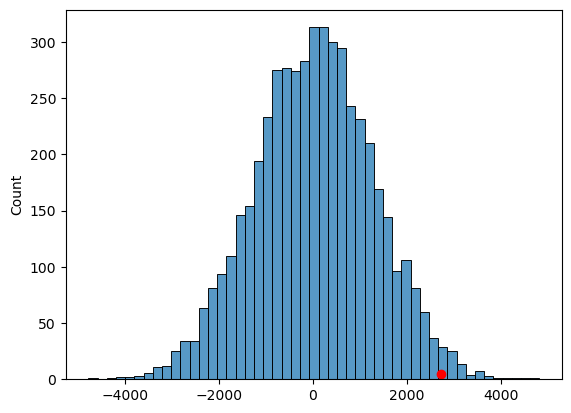

In [77]:
# Visualize results
sns.histplot(diffs_random)
plt.scatter(x=obs_diff_random, y=5, marker='o', color='r');
p_val_random

> With MCAR, dropping rows typically doesn't change our conclusion much — we just have a slightly smaller sample. The data that remains is still representative.

### Simulate MAR, young females more likely to skip

In [79]:
# Generate missing data based on gender/age (MAR)
# Young females are less likely to have salary data
missing_based_on_gender_age = df.copy()
mask = ((missing_based_on_gender_age['gender'] == 'female')
        & (missing_based_on_gender_age['age'] < 30)
        & (np.random.rand(n) < 0.5))
missing_based_on_gender_age.loc[mask, 'salary'] = np.nan

In [80]:
# Drop the rows with missing salary
missing_based_on_gender_age_orig = missing_based_on_gender_age.copy()
missing_based_on_gender_age.dropna(subset='salary', inplace=True)
missing_based_on_gender_age.shape

(477, 3)

In [81]:
# Permutation test after dropping MAR
obs_diff_missing, p_val_missing, diffs_missing = permutation_test(missing_based_on_gender_age, "gender", "salary")

np.float64(0.2748)

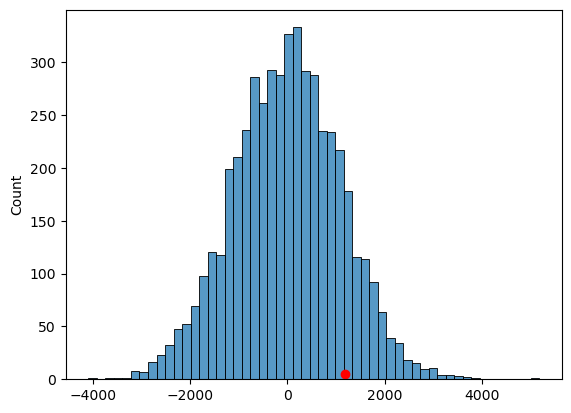

In [82]:
# Visualize results
sns.histplot(diffs_missing)
plt.scatter(x=obs_diff_missing, y=5, marker='o', color='r');
p_val_missing

> With MAR, dropping rows can start to shift our results. We're systematically losing data from one subgroup (young females), which can change the apparent relationship between gender and salary.

### Simulate MNAR, low salaries more likely to be missing

In [83]:
# Generate missing data based on salary itself (MNAR)
# Low salaries are more likely to skip the salary question
missing_based_on_salary = df.copy()
mask = (missing_based_on_salary['salary'] < 55000) & (np.random.rand(n) < 0.7)
missing_based_on_salary.loc[mask, 'salary'] = np.nan

In [84]:
# Drop the rows with missing salary
missing_based_on_salary_orig = missing_based_on_salary.copy()
missing_based_on_salary.dropna(subset='salary', inplace=True)
missing_based_on_salary.shape

(459, 3)

In [85]:
# Permutation test after dropping MNAR
obs_diff_missing2, p_val_missing2, diffs_missing2 = permutation_test(missing_based_on_salary, "gender", "salary")

np.float64(0.0256)

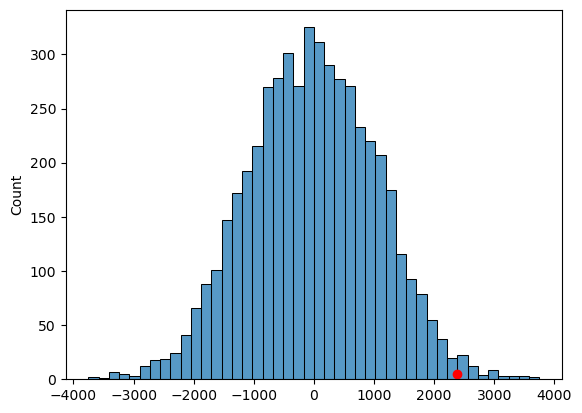

In [86]:
# Visualize results
sns.histplot(diffs_missing2)
plt.scatter(x=obs_diff_missing2, y=5, marker='o', color='r');
p_val_missing2

> With MNAR, dropping can **completely change** our conclusions. By removing low-salary individuals, the remaining data looks different from reality. This is the most dangerous type of missingness.

---
### Try It 2: Explore the Impact 😊

1. Compare the p-values from the four permutation tests above (complete, MCAR, MAR, MNAR). Which types of missingness changed the conclusion? Did any flip the result from significant to non-significant (or vice versa)?

2. Look at the mean salary by gender in `missing_based_on_salary_orig` (before dropping). Then look at it after dropping. How did the means shift?

3. What would happen if instead of 15% MCAR, we had 50% MCAR? Would the conclusion change more? Why or why not?

4. In your own words: why is MNAR the most dangerous type of missing data?

In [87]:
# 1. compare p-values


In [88]:
# 2. mean salary before and after dropping MNAR


In [89]:
# 3. what if 50% MCAR?


In [90]:
# 4. your explanation (double-click markdown cell below to type)


*Your answer: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The key insight: the type of missingness determines whether dropping rows introduces bias.*

```python
# 1. Compare p-values — collect them all
print(f"Complete data p-value:  {p_val}")
print(f"MCAR dropped p-value:  {p_val_random}")
print(f"MAR dropped p-value:   {p_val_missing}")
print(f"MNAR dropped p-value:  {p_val_missing2}")

# 2. Mean salary comparison for MNAR
print("Before dropping (with NaN):")
print(missing_based_on_salary_orig.groupby('gender')['salary'].mean())
print("\nAfter dropping:")
print(missing_based_on_salary.groupby('gender')['salary'].mean())
```

3. With 50% MCAR, you'd lose more statistical power (wider confidence intervals) but the *estimate* of the difference would still be unbiased — just noisier.

4. MNAR is dangerous because the missing values are systematically different from the observed values. No amount of clever analysis on the remaining data can fully recover the true pattern.

</details>

---
## 5. Detecting Missingness Patterns

In practice, you don't *know* what type of missingness you have..... you have to **investigate**. The strategy: create an indicator for whether each value is missing, then check if that indicator is related to other variables.


| Technique | What it reveals | Code |
|-----------|----------------|------|
| `df['col'].isna()` | Boolean mask of missing values | Creates a True/False column |
| `.groupby('cat')['missing_flag'].mean()` | Missingness rate per group | If rates differ → possibly MAR |
| Violin/box plot of numeric var vs missing flag | Distribution differences | If distributions differ → possibly MAR |
| If no patterns found | Likely MCAR | Safe to drop or simple impute |

In [91]:
# Create a "missing salary" indicator column for each dataset

data_random_missing_orig['missing_salary'] = data_random_missing_orig.salary.isna()
missing_based_on_gender_age_orig['missing_salary'] = missing_based_on_gender_age_orig.salary.isna()
missing_based_on_salary_orig['missing_salary'] = missing_based_on_salary_orig.salary.isna()

### Check MCAR: is missingness related to gender or age?

In [92]:
# Check relationship between missingness and gender.... MCAR
data_random_missing_orig.groupby('gender')['missing_salary'].mean()

gender
female    0.164062
male      0.143443
Name: missing_salary, dtype: float64

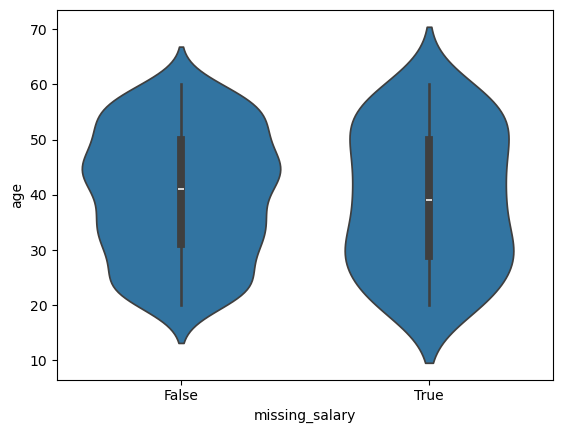

In [93]:
# Check relationship between missingness and age — MCAR
sns.violinplot(x='missing_salary', y='age', data=data_random_missing_orig);

The missingness rates are similar across genders, and the age distributions look the same whether salary is missing or not. No pattern → consistent with **MCAR**.

### Check MAR: is missingness related to gender or age?

In [94]:
# Check relationship between missingness and gender (missing young+females)...... MAR
missing_based_on_gender_age_orig.groupby('gender')['missing_salary'].mean()

gender
female    0.089844
male      0.000000
Name: missing_salary, dtype: float64

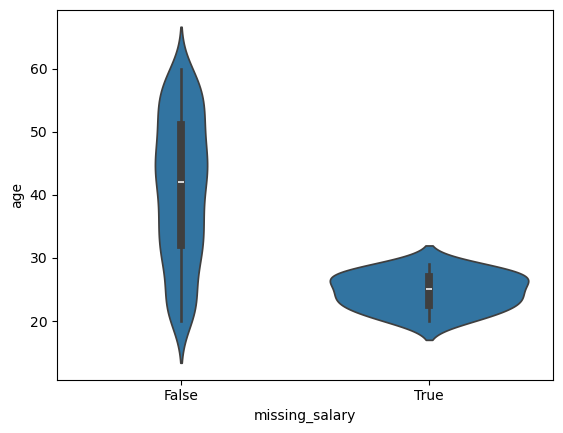

In [95]:
# Check relationship between missingness and age — MAR
sns.violinplot(x='missing_salary', y='age', data=missing_based_on_gender_age_orig);

Now we see a clear pattern: females have a higher missingness rate, and people with missing salaries tend to be younger. This is **MAR** — the missingness is related to observed variables (gender and age).

### Check MNAR: is missingness related to gender or age?

In [96]:
# Check relationship between missingness and gender (missing salary)....MNAR
missing_based_on_salary_orig.groupby('gender')['missing_salary'].mean()

gender
female    0.089844
male      0.073770
Name: missing_salary, dtype: float64

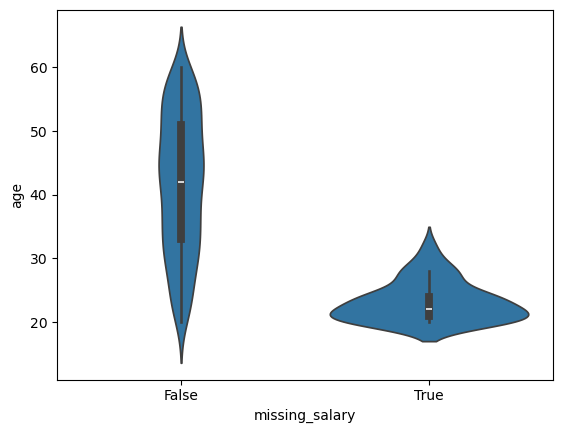

In [97]:
# Check relationship between missingness and age — MNAR
sns.violinplot(x='missing_salary', y='age', data=missing_based_on_salary_orig);

> Here's the tricky part: with MNAR, the missingness *looks* somewhat similar across observed variables. The real pattern (related to salary itself) is hidden because we can't see the missing values! This is why MNAR is so hard to detect — it can masquerade as MCAR.

---
### Try It 3: Investigate Missingness Patterns 😊

1. For the MAR dataset (`missing_based_on_gender_age_orig`), make a bar chart showing the count of missing vs non-missing salary values, split by gender. Which group has more missing data?

2. For the MCAR dataset, try plotting `missing_salary` against `age` using a boxplot instead of a violin plot. Do you see any pattern?

3. Can you think of an additional check you could do to investigate whether the MNAR data is truly MCAR? (Hint: what if you looked at the distribution of *other* variables between the missing and non-missing groups?)

In [98]:
# 1. bar chart of missing vs non-missing by gender (MAR)


In [99]:
# 2. boxplot of age vs missing_salary (MCAR)


In [100]:
# 3. additional investigation for MNAR


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Looking at missingness from multiple angles helps you build confidence about the type.*

```python
# 1.
sns.countplot(data=missing_based_on_gender_age_orig, x='gender', hue='missing_salary');

# 2.
sns.boxplot(x='missing_salary', y='age', data=data_random_missing_orig);
# No pattern — age distributions are similar whether salary is missing or not

# 3. For MNAR, you might check if the age distribution differs between
# missing and non-missing groups — it shouldn't (since missingness is
# based on salary, not age), which makes MNAR look like MCAR!
sns.boxplot(x='missing_salary', y='age', data=missing_based_on_salary_orig);
```

</details>

---
## 6. Visualizing Missingness with `missingno`

Checking patterns one variable at a time works, but the `missingno` library gives us specialized visualizations that make it much easier to spot patterns — especially in larger datasets.

> **Installation note:** If you get import errors:
> ```
> conda activate data271
> python -m pip install missingno
> ```
> Restart kernel and try again.

In [101]:
import missingno as msno

ModuleNotFoundError: No module named 'missingno'

### Bar chart — proportion of non-missing values

In [102]:
# Bar chart showing completeness of each column
msno.bar(missing_based_on_gender_age_orig);

NameError: name 'msno' is not defined

### Missing matrix — row-by-row view

The missing matrix shows every row of data. White gaps = missing values. This is powerful because you can **sort** by different columns to reveal patterns.

In [ ]:
# Missing matrix — default order
msno.matrix(missing_based_on_gender_age_orig);

In [ ]:
# Sort by age to see if missingness clusters among certain ages
sorted_df = missing_based_on_gender_age_orig.sort_values('age')
msno.matrix(sorted_df);

This makes it clear that only younger individuals skipped the salary question — the white gaps cluster at the top (youngest ages) of the sorted matrix.

In [ ]:
# Sort by gender to see if missingness clusters by gender
sorted_df = missing_based_on_gender_age_orig.sort_values('gender')
msno.matrix(sorted_df);

This reveals that missingness is also correlated with gender — one group has noticeably more white gaps than the other.

> **Pro tip:** When investigating missingness, try sorting the matrix by different columns. If the white gaps cluster after sorting, that variable is related to the missingness pattern.

---
### Try It 4: Explore with `missingno` 😊

1. Create a `missingno` matrix for the **MCAR** dataset (`data_random_missing_orig`). Sort by age, then by gender. Do you see any patterns? (You shouldn't!)

2. Create a `missingno` matrix for the **MNAR** dataset (`missing_based_on_salary_orig`). Sort by age, then by gender. Does it look different from MCAR?

3. Why is it hard to detect MNAR using `missingno`? What information would you need that you don't have?

In [ ]:
# 1. missingno matrix for MCAR — sort by age


In [ ]:
# 1b. missingno matrix for MCAR — sort by gender


In [ ]:
# 2. missingno matrix for MNAR — sort by age


In [ ]:
# 2b. missingno matrix for MNAR — sort by gender


*Your answer to 3: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*MNAR is invisible to missingno because the pattern depends on the very values that are missing.*

```python
# 1.
sorted_mcar = data_random_missing_orig.sort_values('age')
msno.matrix(sorted_mcar);
# No clustering — gaps are scattered randomly

sorted_mcar = data_random_missing_orig.sort_values('gender')
msno.matrix(sorted_mcar);
# Still no pattern

# 2.
sorted_mnar = missing_based_on_salary_orig.sort_values('age')
msno.matrix(sorted_mnar);
# Looks random-ish — hard to tell from MCAR!

sorted_mnar = missing_based_on_salary_orig.sort_values('gender')
msno.matrix(sorted_mnar);
```

3. MNAR is hard to detect because the missingness depends on the *missing values themselves* (salary), which we can't observe. We'd need the actual missing salary values to confirm the pattern — but if we had those, they wouldn't be missing!

</details>

---
## 7. Handling Missing Data — Simple Imputation

Now that we understand the types of missingness, let's look at our options for handling it. We have three main approaches, and the right choice depends on the type of missingness.

### Handling Strategies

| Option | Method | Best for | Code |
|--------|--------|----------|------|
| **Drop** | Remove missing rows/columns | MCAR with few missing values | `df.dropna()` |
| **Simple imputation** | Fill with mean, median, or mode | MCAR, sometimes MAR | `df.fillna(df['col'].mean())` |
| **Advanced imputation** | Model-based (regression, ML) | MAR, sometimes MNAR | Various (beyond this course) |

###  `dropna()` Options

| Code | What it does |
|------|-------------|
| `df.dropna()` | Drop rows with *any* missing value |
| `df.dropna(axis='columns')` | Drop *columns* with any missing value |
| `df.dropna(subset=['col1', 'col2'])` | Drop rows only if specified columns are missing |
| `df.dropna(thresh=N)` | Keep rows that have at least N non-null values |

### `fillna()` Options

| Code | What it does |
|------|-------------|
| `df['col'].fillna(value)` | Fill with a specific value |
| `df['col'].fillna(df['col'].mean())` | Fill with the column mean |
| `df['col'].fillna(df['col'].median())` | Fill with the column median |
| `df.ffill()` | Forward fill (use previous value) |
| `df.bfill()` | Backward fill (use next value) |

### Comparing imputation strategies visually

Let's see what mean imputation looks like compared to the original data for each type of missingness.

In [103]:
# Fill MCAR with the mean
MCAR_filled = data_random_missing_orig.copy()
MCAR_filled['salary'] = MCAR_filled['salary'].fillna(MCAR_filled['salary'].mean())

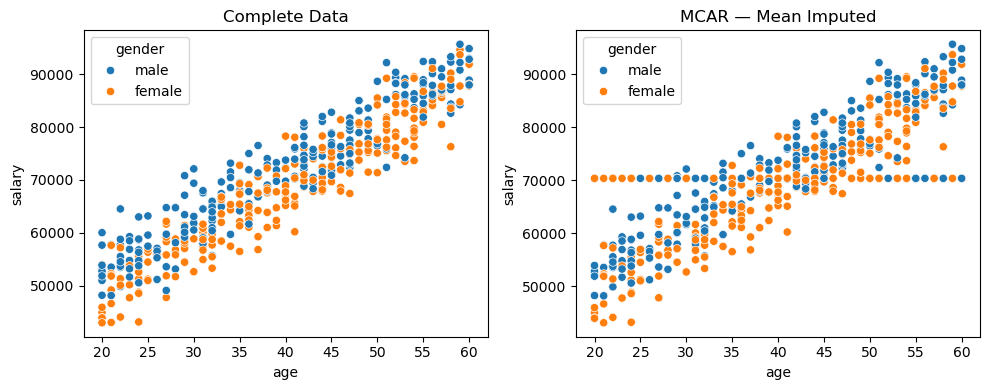

In [104]:
# Compare: complete data vs mean-imputed MCAR
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x='age', y='salary', hue='gender', ax=ax[0])
ax[0].set_title('Complete Data')
sns.scatterplot(data=MCAR_filled, x='age', y='salary', hue='gender', ax=ax[1])
ax[1].set_title('MCAR — Mean Imputed')
plt.tight_layout();

Notice the horizontal line of points at the mean — those are the imputed values. For MCAR, they're scattered across both genders and all ages, which is reasonable.

In [105]:
# Fill MAR with the mean
MAR_filled = missing_based_on_gender_age_orig.copy()
MAR_filled['salary'] = MAR_filled['salary'].fillna(MAR_filled['salary'].mean())

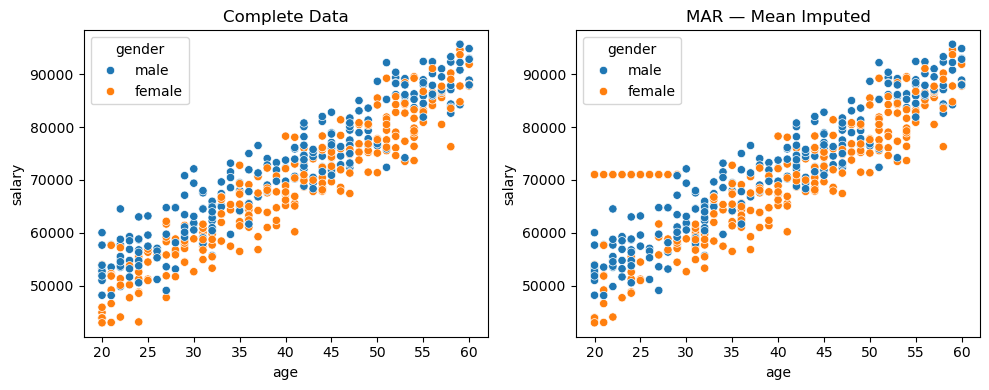

In [106]:
# Compare: complete data vs mean-imputed MAR
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x='age', y='salary', hue='gender', ax=ax[0])
ax[0].set_title('Complete Data')
sns.scatterplot(data=MAR_filled, x='age', y='salary', hue='gender', ax=ax[1])
ax[1].set_title('MAR — Mean Imputed')
plt.tight_layout();

See the problem? The imputed values (horizontal line) are concentrated among young females — because that's who had missing data. We're giving all of them the *overall* mean salary, which might not reflect what young female salaries actually look like.

In [107]:
# Fill MNAR with the mean
MNAR_filled = missing_based_on_salary_orig.copy()
MNAR_filled['salary'] = MNAR_filled['salary'].fillna(MNAR_filled['salary'].mean())

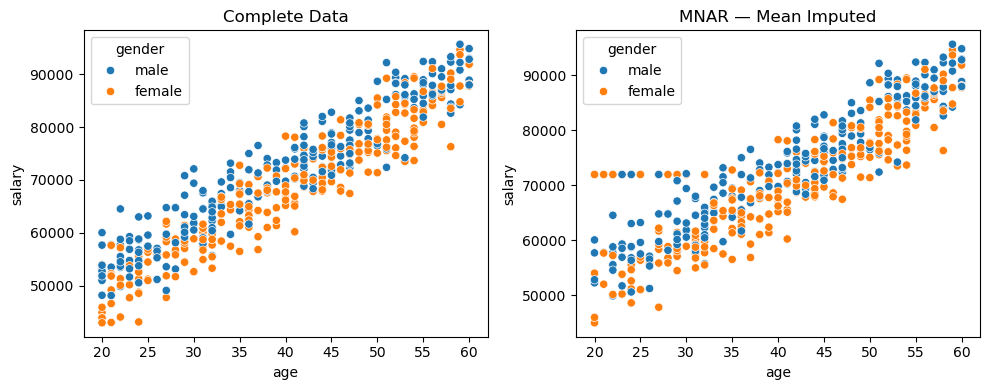

In [108]:
# Compare: complete data vs mean-imputed MNAR
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x='age', y='salary', hue='gender', ax=ax[0])
ax[0].set_title('Complete Data')
sns.scatterplot(data=MNAR_filled, x='age', y='salary', hue='gender', ax=ax[1])
ax[1].set_title('MNAR — Mean Imputed')
plt.tight_layout();

> With MNAR, the people who were missing had *low* salaries, but we filled them with the *overall mean* — a much higher value. This is clearly wrong and will bias our analysis upward.

### How do these imputation strategies affect the permutation test?

Let's check if filling with the mean or median changes our statistical conclusions.

In [109]:
# MCAR — fill with mean, then test
random_filled_mean = data_random_missing_orig.copy()
random_filled_mean['salary'] = random_filled_mean['salary'].fillna(random_filled_mean['salary'].mean())
obs_diff, p_val, diffs = permutation_test(random_filled_mean, "gender", "salary")
print(f"MCAR + mean fill: p = {p_val}")

MCAR + mean fill: p = 0.0186


In [110]:
# MCAR — fill with median, then test
random_filled_med = data_random_missing_orig.copy()
random_filled_med['salary'] = random_filled_med['salary'].fillna(random_filled_med['salary'].median())
obs_diff, p_val, diffs = permutation_test(random_filled_med, "gender", "salary")
print(f"MCAR + median fill: p = {p_val}")

MCAR + median fill: p = 0.0164


In [111]:
# MAR — fill with mean, then test
MAR_filled_mean = missing_based_on_gender_age_orig.copy()
MAR_filled_mean['salary'] = MAR_filled_mean['salary'].fillna(MAR_filled_mean['salary'].mean())
obs_diff, p_val, diffs = permutation_test(MAR_filled_mean, "gender", "salary")
print(f"MAR + mean fill: p = {p_val}")

MAR + mean fill: p = 0.2718


In [112]:
# MAR — fill with median, then test
MAR_filled_med = missing_based_on_gender_age_orig.copy()
MAR_filled_med['salary'] = MAR_filled_med['salary'].fillna(MAR_filled_med['salary'].median())
obs_diff, p_val, diffs = permutation_test(MAR_filled_med, "gender", "salary")
print(f"MAR + median fill: p = {p_val}")

MAR + median fill: p = 0.2804


In [113]:
# MNAR — fill with mean, then test
MNAR_filled_mean = missing_based_on_salary_orig.copy()
MNAR_filled_mean['salary'] = MNAR_filled_mean['salary'].fillna(MNAR_filled_mean['salary'].mean())
obs_diff, p_val, diffs = permutation_test(MNAR_filled_mean, "gender", "salary")
print(f"MNAR + mean fill: p = {p_val}")

MNAR + mean fill: p = 0.0182


In [114]:
# MNAR — fill with median, then test
MNAR_filled_med = missing_based_on_salary_orig.copy()
MNAR_filled_med['salary'] = MNAR_filled_med['salary'].fillna(MNAR_filled_med['salary'].median())
obs_diff, p_val, diffs = permutation_test(MNAR_filled_med, "gender", "salary")
print(f"MNAR + median fill: p = {p_val}")

MNAR + median fill: p = 0.0212


---
### Try It 5: Compare Imputation Strategies 😊

1. For the **MAR** dataset, try filling missing salaries with the **group mean** (mean salary *within each gender*) instead of the overall mean. Does this improve the result? Hint: use `.groupby('gender')['salary'].transform('mean')`.

2. Make side-by-side scatter plots comparing: (a) overall mean imputation vs (b) group mean imputation for the MAR dataset. Which looks more realistic?

3. For the **MCAR** dataset, does it matter much whether you use mean vs median imputation? Why or why not?

In [ ]:
# 1. group-mean imputation for MAR


In [ ]:
# 2. compare scatter plots


In [ ]:
# 3. mean vs median for MCAR


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*When data is MAR, imputing within subgroups can reduce bias because missingness is related to group membership.*

```python
# 1. Group mean imputation
MAR_group_filled = missing_based_on_gender_age_orig.copy()
group_means = MAR_group_filled.groupby('gender')['salary'].transform('mean')
MAR_group_filled['salary'] = MAR_group_filled['salary'].fillna(group_means)

obs_diff, p_val, diffs = permutation_test(MAR_group_filled, "gender", "salary")
print(f"MAR + group mean fill: p = {p_val}")

# 2. Visual comparison
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=MAR_filled, x='age', y='salary', hue='gender', ax=ax[0])
ax[0].set_title('Overall Mean Imputed')
sns.scatterplot(data=MAR_group_filled, x='age', y='salary', hue='gender', ax=ax[1])
ax[1].set_title('Group Mean Imputed')
plt.tight_layout()

# 3. For MCAR, mean and median give very similar results because the
# missingness is random — neither introduces systematic bias.
```

</details>

---
## 8. Handling Missing Data — Time Series Methods

Imputing with the mean, median, or mode is not always the best option — especially for **sequential** or **time series** data, where values follow a temporal pattern.

Let's see why with a real dataset.

### ETL — Air Quality dataset

In [115]:
airquality = pd.read_csv("airquality.csv")
airquality.head()

,Date,Ozone,Solar.R,Wind,Hours.Of.Daylight,Temp,Month,Day
0,5/1/76,41.0,190.0,7.4,14.000000,67,5,1
1,5/2/76,36.0,118.0,8.0,14.082668,72,5,2
2,5/3/76,12.0,149.0,12.6,14.165300,74,5,3
3,5/4/76,18.0,313.0,11.5,14.247862,62,5,4
4,5/5/76,NaN,NaN,14.3,14.330317,56,5,5


In [116]:
airquality.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               153 non-null    str    
 1   Ozone              116 non-null    float64
 2   Solar.R            146 non-null    float64
 3   Wind               153 non-null    float64
 4   Hours.Of.Daylight  138 non-null    float64
 5   Temp               153 non-null    int64  
 6   Month              153 non-null    int64  
 7   Day                153 non-null    int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 9.7 KB


In [117]:
airquality['Date'] = pd.to_datetime(airquality['Date'])
airquality.head()

,Date,Ozone,Solar.R,Wind,Hours.Of.Daylight,Temp,Month,Day
0,1976-05-01,41.0,190.0,7.4,14.000000,67,5,1
1,1976-05-02,36.0,118.0,8.0,14.082668,72,5,2
2,1976-05-03,12.0,149.0,12.6,14.165300,74,5,3
3,1976-05-04,18.0,313.0,11.5,14.247862,62,5,4
4,1976-05-05,NaN,NaN,14.3,14.330317,56,5,5


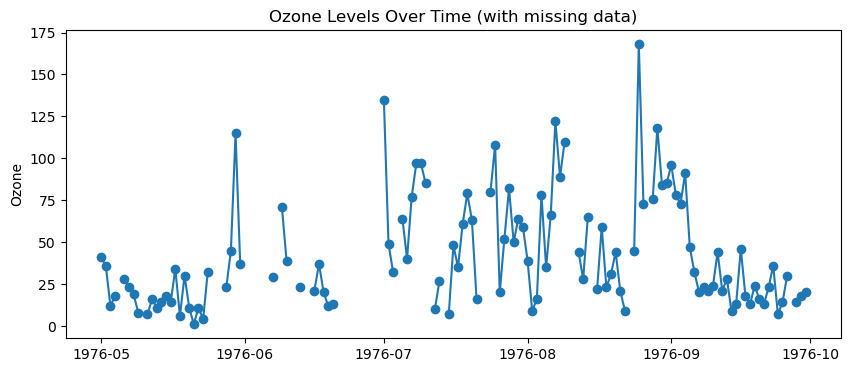

In [118]:
# Look at the Ozone data — notice the gaps where data is missing
plt.figure(figsize=(10, 4))
plt.plot(airquality["Date"], airquality["Ozone"], marker='o')
plt.ylabel('Ozone')
plt.title('Ozone Levels Over Time (with missing data)')
plt.show()

The time series varies a lot — it goes up and down with a pattern. If we just fill everything with the mean, we'd be putting a flat line through all the gaps. That doesn't respect the temporal structure at all.

### Why mean imputation fails for time series

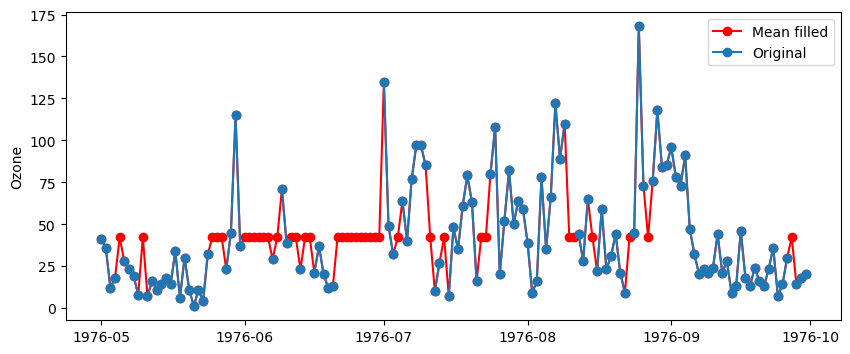

In [119]:
# Fill NaN with the mean — see the problem?
mean_fill = airquality.copy()
mean_fill['Ozone'] = mean_fill['Ozone'].fillna(airquality.Ozone.mean())

plt.figure(figsize=(10, 4))
plt.plot(mean_fill["Date"], mean_fill["Ozone"], marker='o', color='r', label='Mean filled')
plt.plot(airquality["Date"], airquality["Ozone"], marker='o', label='Original')
plt.ylabel('Ozone')
plt.legend()
plt.show()

The red dots jump to the mean value regardless of what the surrounding values look like. Not great. Let's look at better options.

### 📋 Board Reference — Time Series Imputation

| Method | Code | How it works | Best when... |
|--------|------|-------------|-------------|
| **Forward fill** | `df.ffill()` | Copies the previous value forward | Values change slowly |
| **Backward fill** | `df.bfill()` | Copies the next value backward | You trust future values |
| **Linear interpolation** | `df['col'].interpolate(method='linear')` | Draws a straight line between neighbors | Smooth trends |
| **Other interpolation** | `df['col'].interpolate(method='quadratic')` | Fits curves between neighbors | Very smooth data |
| **Random sample** | Sample from non-NaN values | Randomly picks observed values | MCAR, preserves distribution |

### Forward fill

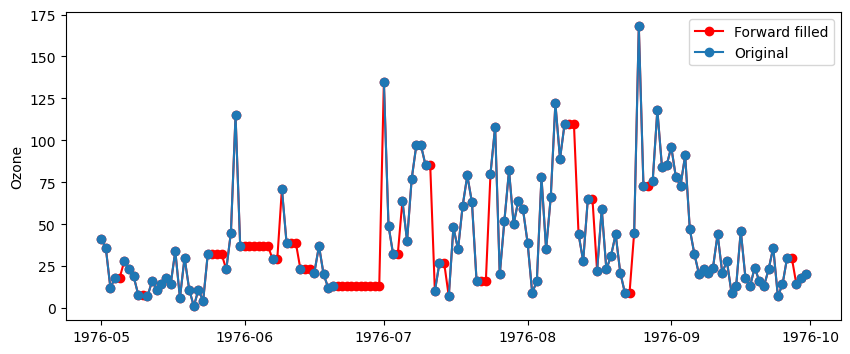

In [120]:
# Forward fill — each NaN gets the value of the previous row
forward_fill = airquality.copy()
forward_fill = forward_fill.ffill()

plt.figure(figsize=(10, 4))
plt.plot(forward_fill["Date"], forward_fill["Ozone"], marker='o', color='r', label='Forward filled')
plt.plot(airquality["Date"], airquality["Ozone"], marker='o', label='Original')
plt.ylabel('Ozone')
plt.legend()
plt.show()

Forward fill creates "staircase" patterns — the last known value is held constant until a new observation appears. This works well when values don't change rapidly.

### Backward fill

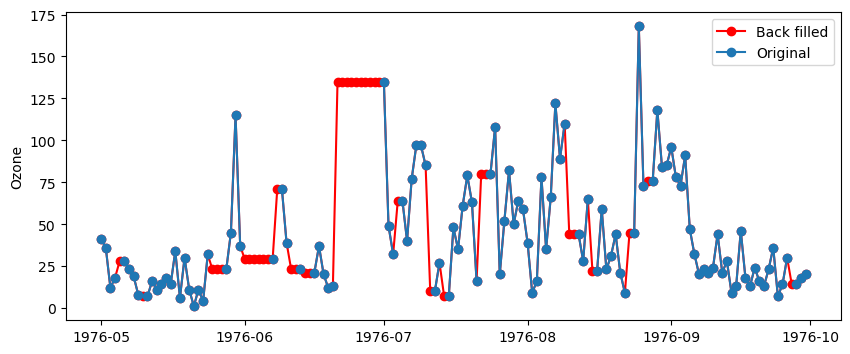

In [121]:
# Backward fill — each NaN gets the value of the NEXT row
back_fill = airquality.copy()
back_fill = back_fill.bfill()

plt.figure(figsize=(10, 4))
plt.plot(back_fill["Date"], back_fill["Ozone"], marker='o', color='r', label='Back filled')
plt.plot(airquality["Date"], airquality["Ozone"], marker='o', label='Original')
plt.ylabel('Ozone')
plt.legend()
plt.show()

### Linear interpolation

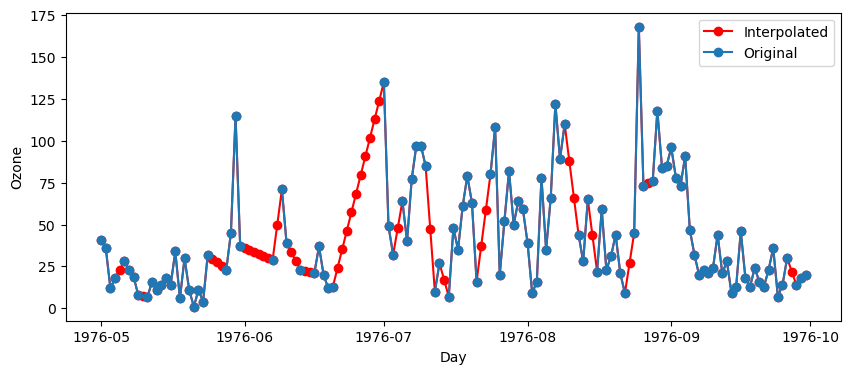

In [122]:
# Linear interpolation — draw a straight line between the two nearest known values
interpolated_oz = airquality.copy()
interpolated_oz['Ozone'] = airquality.Ozone.interpolate(method='linear')

plt.figure(figsize=(10, 4))
plt.plot(interpolated_oz["Date"], interpolated_oz["Ozone"], marker='o', color='r', label='Interpolated')
plt.plot(airquality["Date"], airquality["Ozone"], marker='o', label='Original')
plt.xlabel('Day')
plt.ylabel('Ozone')
plt.legend()
plt.show()

This looks like a reasonable guess! The filled values transition smoothly between the known data points.

> **Note:** There are other interpolation methods too. Let's try quadratic...

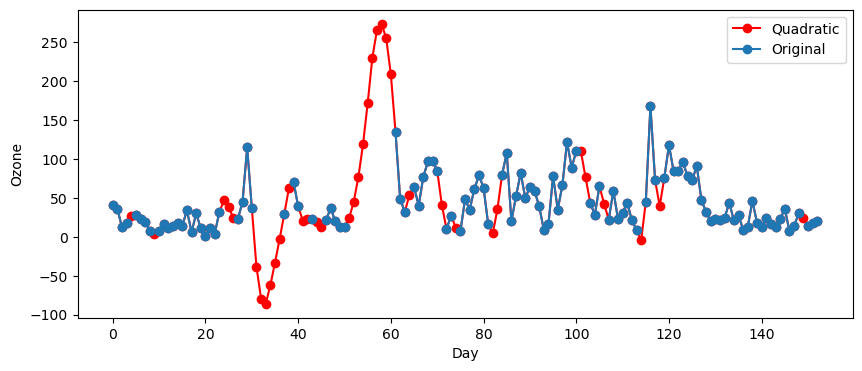

In [123]:
# Quadratic interpolation — fits a curve instead of a straight line
interpolated_quad = airquality.copy()
interpolated_quad['Ozone'] = airquality.Ozone.interpolate(method='quadratic')

plt.figure(figsize=(10, 4))
interpolated_quad['Ozone'].plot(color='r', marker='o', label='Quadratic')
airquality['Ozone'].plot(marker='o', label='Original')
plt.xlabel('Day')
plt.ylabel('Ozone')
plt.legend()
plt.show()

> Yikes — quadratic interpolation **highly overshot** the data ranges here. Just because a method is fancier doesn't mean it's better! Always visualize your imputation to check if it's reasonable.

### Random sampling from observed values

One more option: fill missing values by randomly sampling from the non-missing values. This preserves the overall distribution shape and works for both numeric and categorical data.

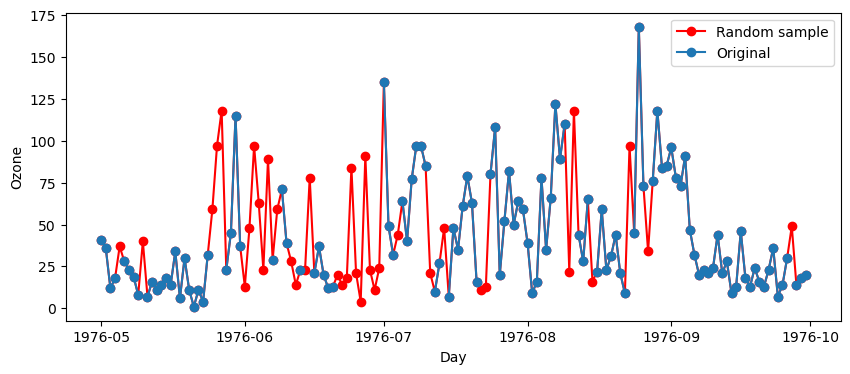

In [124]:
# Random sample imputation
non_nan_values = airquality['Ozone'].dropna()
nan_count = airquality['Ozone'].isna().sum()
random_samples = np.random.choice(non_nan_values, nan_count, replace=True)

random_fill = airquality.copy()
random_fill.loc[random_fill['Ozone'].isna(), 'Ozone'] = random_samples

plt.figure(figsize=(10, 4))
plt.plot(random_fill["Date"], random_fill["Ozone"], marker='o', color='r', label='Random sample')
plt.plot(airquality["Date"], airquality["Ozone"], marker='o', label='Original')
plt.xlabel('Day')
plt.ylabel('Ozone')
plt.legend()
plt.show()

Random sampling doesn't respect the time ordering (a high value might get placed in a low-ozone period), but it keeps the overall distribution intact. This can be useful when the data is MCAR or MAR and you don't have a strong temporal pattern to leverage.

---
### Try It 6: Pick the Best Method 😊

1. Look at the `Hours.Of.Daylight` column in the `airquality` dataset. Plot it. What pattern do you see? Fill in the missing values with the **most appropriate method** and explain your choice.

2. Compare forward fill vs linear interpolation on the Ozone column. Plot them side by side. Which one looks more natural for this data?

3. Try using `.interpolate(method='linear', limit=3)` on the Ozone column. What does the `limit` parameter do? When might you want to limit how far interpolation reaches?

4. **Challenge:** Can you think of a scenario where forward fill would be *better* than interpolation? (Hint: think about categorical data or step-function-like data.)

In [ ]:
# 1. explore Hours.Of.Daylight and impute


In [ ]:
# 2. compare forward fill vs interpolation side by side


In [ ]:
# 3. try limit parameter


In [ ]:
# 4. your answer (type in markdown cell below)


*Your answer to 4: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*For time series, the right method depends on the pattern of the data — always plot first!*

```python
# 1. Hours of daylight follows a smooth seasonal pattern
plt.figure(figsize=(10, 4))
plt.plot(airquality["Date"], airquality["Hours.Of.Daylight"], marker='o')
plt.ylabel('Hours of Daylight')
plt.show()

# Linear interpolation is great for smooth, predictable patterns
daylight_filled = airquality.copy()
daylight_filled['Hours.Of.Daylight'] = airquality['Hours.Of.Daylight'].interpolate(method='linear')

plt.figure(figsize=(10, 4))
plt.plot(daylight_filled["Date"], daylight_filled["Hours.Of.Daylight"], marker='o', color='r')
plt.plot(airquality["Date"], airquality["Hours.Of.Daylight"], marker='o')
plt.ylabel('Hours of Daylight')
plt.show()

# 2. Side by side comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ffill_oz = airquality.copy().ffill()
interp_oz = airquality.copy()
interp_oz['Ozone'] = airquality.Ozone.interpolate(method='linear')

ax[0].plot(ffill_oz["Date"], ffill_oz["Ozone"], marker='o', color='r')
ax[0].plot(airquality["Date"], airquality["Ozone"], marker='o')
ax[0].set_title('Forward Fill')
ax[1].plot(interp_oz["Date"], interp_oz["Ozone"], marker='o', color='r')
ax[1].plot(airquality["Date"], airquality["Ozone"], marker='o')
ax[1].set_title('Linear Interpolation')
plt.tight_layout()

# 3. limit=3 only fills gaps of 3 or fewer consecutive NaNs.
# Longer gaps are left as NaN — useful when you don't trust
# interpolation over large stretches of missing data.
```

4. Forward fill is better for **categorical** data (e.g., a patient's medication status — it stays the same until changed) or **step-function** data (e.g., a price that holds steady until the next price change).

</details>

---
## 9. 🔬 Open Exploration — Lake Mendocino

Let's put it all together with a real dataset! Lake Mendocino is a reservoir in Northern California. This dataset tracks water levels over a year.

Run the cells below to load and clean the data, then investigate the missing values and choose an imputation strategy.

In [ ]:
# Import the Lake Mendocino dataset
lake = pd.read_csv('coy_wy2024_csvdata.csv')
lake.head()

In [ ]:
# Clean up the dataset
lake[lake == '-'] = np.nan
notes_columns = [col for col in lake.columns if 'notes' in col]
lake[notes_columns] = lake[notes_columns].replace(0, np.nan)
lake.dropna(axis=1, thresh=230, inplace=True)
lake = lake.assign(
    cons_high=lake['Top of Conservation High (ac-ft)'].astype(float),
    cons=lake['Top of Conservation (ac-ft)'].astype(float),
    gross_pool=lake['Gross Pool'].astype(float),
    gross_pool_elev=lake['Gross Pool(elev)'].astype(float)
)
lake['date'] = pd.to_datetime(lake['ISO 8601 Date Time'].str[:10])
lake.drop(columns=['Top of Conservation High (ac-ft)',
                    'Top of Conservation (ac-ft)',
                    'Gross Pool', 'Gross Pool(elev)'], inplace=True)
lake.head()

In [ ]:
lake.info()

**Prompt 1 — Investigate the missingness:**

Check which columns have missing data. Use `missingno` to visualize the pattern. What type of missingness do you think this is?

In [ ]:
# Prompt 1 — investigate


**Prompt 2 — Choose and apply an imputation method:**

This is time series data (daily measurements). Choose the most appropriate imputation method for this dataset. Fill in the null values and verify your imputation worked.

In [ ]:
# Prompt 2 — impute


**Prompt 3 — Visualize and evaluate:**

Plot your imputed data alongside the original. Does your imputation look reasonable? Try at least two different methods and compare.

In [ ]:
# Prompt 3 — visualize


*Your interpretation: (double-click to edit)*

<details>
<summary>💡 One approach — click to peek</summary>
<br>

*Lake level data is sequential — interpolation or forward fill are natural choices.*

```python
# Investigate
msno.matrix(lake);
print(lake.isnull().sum())

# Impute with linear interpolation (good for smooth time series)
lake_filled = lake.copy()
numeric_cols = lake.select_dtypes(include='number').columns
for col in numeric_cols:
    lake_filled[col] = lake_filled[col].interpolate(method='linear')

# Check it worked
print(lake_filled.isnull().sum())

# Plot — example with cons column
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(lake['date'], lake['cons'], marker='.', markersize=3)
ax[0].set_title('Original (with gaps)')
ax[0].set_ylabel('Conservation (ac-ft)')
ax[1].plot(lake_filled['date'], lake_filled['cons'], marker='.', markersize=3, color='r')
ax[1].set_title('Interpolated')
ax[1].set_ylabel('Conservation (ac-ft)')
plt.tight_layout()
```

</details>

---
## Appendix — Missing Data Quick Reference

### Summary: Type → Approach

| Type | Approach |
|------|----------|
| **MCAR** | Drop or simple imputation (mean/median) |
| **MAR** | More advanced fill methods, group-based imputation, multiple imputation |
| **MNAR** | Case-by-case — no simple fix |

### Workflow for treating missing values

1. **Define your intended analysis** — what columns are needed? What biases could impact conclusions?
2. **Explore the relationship** between missing values and other variables to roughly determine the type
3. **Decide on an approach:**
   - a. Drop missing values
   - b. Impute missing values (mean, median, ffill, interpolate, etc.)
   - c. Advanced/multiple imputation
4. **Evaluate & compare** multiple approaches (sensitivity analysis)

### Minimal template — detect and fill
```python
# Check for missing data
df.isnull().sum()
df.info()

# Investigate patterns
df['missing_flag'] = df['col'].isna()
df.groupby('group_col')['missing_flag'].mean()

# Simple fill
df['col'].fillna(df['col'].mean(), inplace=True)
```

### Full template — time series imputation
```python
# Visualize gaps
import missingno as msno
msno.matrix(df)

# Forward fill
df = df.ffill()

# Linear interpolation
df['col'] = df['col'].interpolate(method='linear')

# Verify
df.isnull().sum()
plt.plot(df['date'], df['col'])
```